## 30-day chart challenge

#### comparison: historical

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
import requests
from io import StringIO

url = "https://ourworldindata.org/grapher/annual-working-hours-per-worker.csv"

headers = {"User-Agent": "Mozilla/5.0"}  # avoids 403 Forbidden
response = requests.get(url, headers=headers)
df = pd.read_csv(StringIO(response.text))

In [17]:
df

,Entity,Code,Year,Working hours per worker
0,Albania,ALB,2005,2343.90
1,Albania,ALB,2006,2333.12
2,Albania,ALB,2007,2334.51
3,Albania,ALB,2008,2195.57
4,Albania,ALB,2009,2191.19
...,...,...,...,...
5058,Zimbabwe,ZWE,2019,1903.71
5059,Zimbabwe,ZWE,2020,1889.45
5060,Zimbabwe,ZWE,2021,2011.57
5061,Zimbabwe,ZWE,2022,2172.04


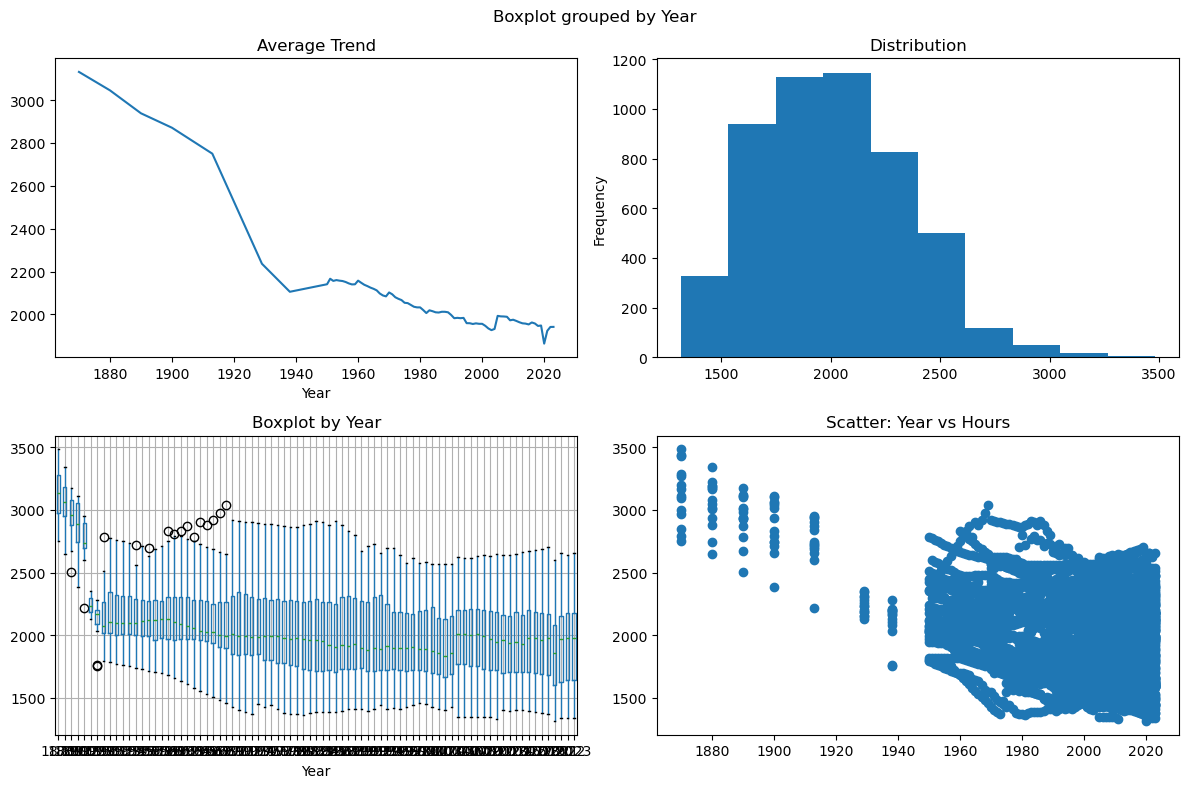

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Line plot (overall trend)
df.groupby('Year')['Working hours per worker'].mean().plot(ax=axes[0,0], title='Average Trend')

# 2. Histogram
df['Working hours per worker'].plot(kind='hist', ax=axes[0,1], title='Distribution')

# 3. Box plot
df.boxplot(column='Working hours per worker', by='Year', ax=axes[1,0])
axes[1,0].set_title('Boxplot by Year')

# 4. Scatter plot
axes[1,1].scatter(df['Year'], df['Working hours per worker'])
axes[1,1].set_title('Scatter: Year vs Hours')

plt.tight_layout()
plt.show()